# Explore here

In [2]:
#Step 0: Libraries
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import pickle  # para guardar el modelo

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")


In [4]:
#Step 1: Import data

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)


X_train: (614, 8) | X_test: (154, 8)
y_train: (614,) | y_test: (154,)


In [5]:
#Step 2: ML

boost_base = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

boost_base.fit(X_train, y_train)
y_pred_base = boost_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
print("Accuracy Boosting (base):", acc_base)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_base))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_base))


Accuracy Boosting (base): 0.7597402597402597

Matriz de confusión:
[[86 14]
 [23 31]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       100
           1       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



n_estimators=50 -> accuracy=0.7468
n_estimators=100 -> accuracy=0.7597
n_estimators=200 -> accuracy=0.7597
n_estimators=300 -> accuracy=0.7532
n_estimators=500 -> accuracy=0.7403


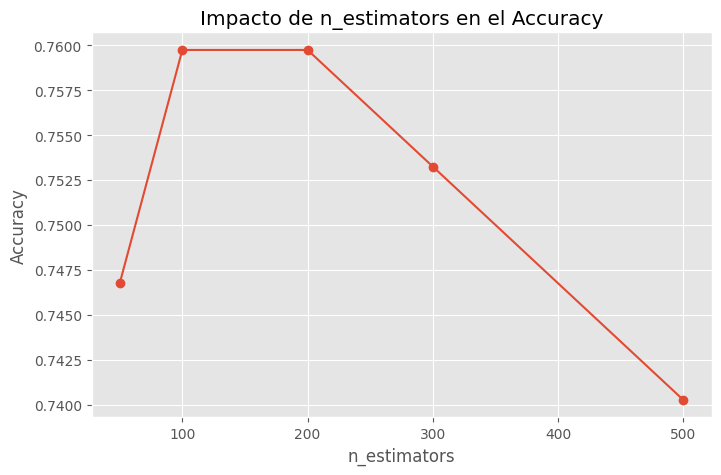

In [7]:
#Analisis de estimadores
n_estimators_list = [50, 100, 200, 300, 500]
acc_estimators = []

for n in n_estimators_list:
    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    acc_estimators.append(acc)
    print(f"n_estimators={n} -> accuracy={acc:.4f}")

plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, acc_estimators, marker="o")
plt.title("Impacto de n_estimators en el Accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


learning_rate=0.001 -> accuracy=0.6494
learning_rate=0.01 -> accuracy=0.7208
learning_rate=0.05 -> accuracy=0.7597
learning_rate=0.1 -> accuracy=0.7597
learning_rate=0.2 -> accuracy=0.7338


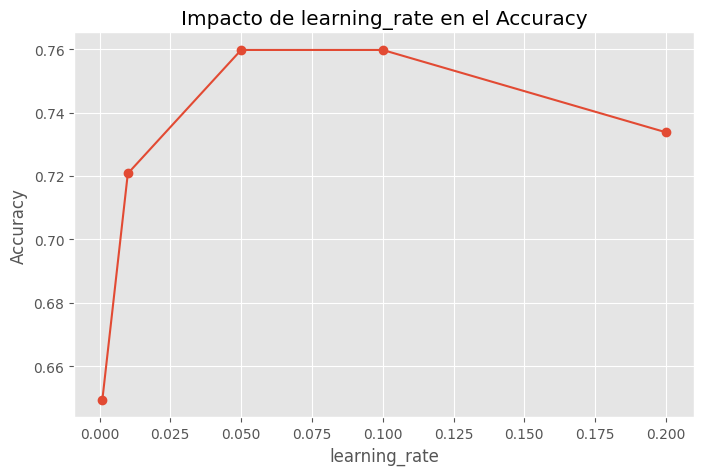

In [9]:
#Learning rate
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2]
acc_lr = []

for lr in learning_rates:
    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    acc_lr.append(acc)
    print(f"learning_rate={lr} -> accuracy={acc:.4f}")

plt.figure(figsize=(8,5))
plt.plot(learning_rates, acc_lr, marker="o")
plt.title("Impacto de learning_rate en el Accuracy")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


max_depth=1 -> accuracy=0.7597
max_depth=2 -> accuracy=0.7662
max_depth=3 -> accuracy=0.7597
max_depth=4 -> accuracy=0.7468
max_depth=5 -> accuracy=0.7532


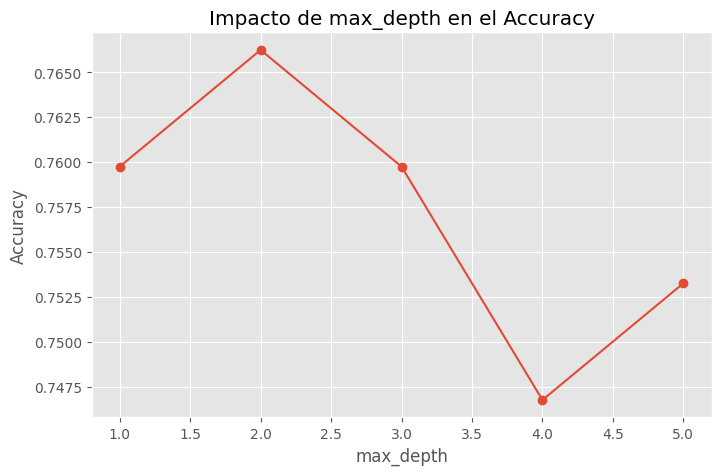

In [10]:
#Max depth
max_depth_list = [1, 2, 3, 4, 5]
acc_depth = []

for d in max_depth_list:
    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=d,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    acc_depth.append(acc)
    print(f"max_depth={d} -> accuracy={acc:.4f}")

plt.figure(figsize=(8,5))
plt.plot(max_depth_list, acc_depth, marker="o")
plt.title("Impacto de max_depth en el Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [11]:
#Entrenar al mejor modelo
best_boost = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

best_boost.fit(X_train, y_train)
y_pred_best = best_boost.predict(X_test)

print("Accuracy mejor Boosting:", accuracy_score(y_test, y_pred_best))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_best))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_best))


Accuracy mejor Boosting: 0.7207792207792207

Matriz de confusión:
[[83 17]
 [26 28]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



In [12]:
#Guardar modelo
os.makedirs("models", exist_ok=True)

with open("models/boosting_diabetes.pkl", "wb") as f:
    pickle.dump(best_boost, f)

print("Modelo guardado en models/boosting_diabetes.pkl")


Modelo guardado en models/boosting_diabetes.pkl


In [17]:
results = pd.DataFrame({
    "Modelo": ["Decision Tree", "Random Forest", "Boosting"],
    "Accuracy": [
        0.6948051948051948,
        0.74062597402597403,
        accuracy_score(y_test, y_pred_best)
    ]
})

results


,Modelo,Accuracy
0,Decision Tree,0.694805
1,Random Forest,0.740626
2,Boosting,0.720779


In [18]:
print("Boosting Classification Report:")
print(classification_report(y_test, y_pred_best))


Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154

